Found 52 quarters of data.
Downloading...
Stitching...
Plotting


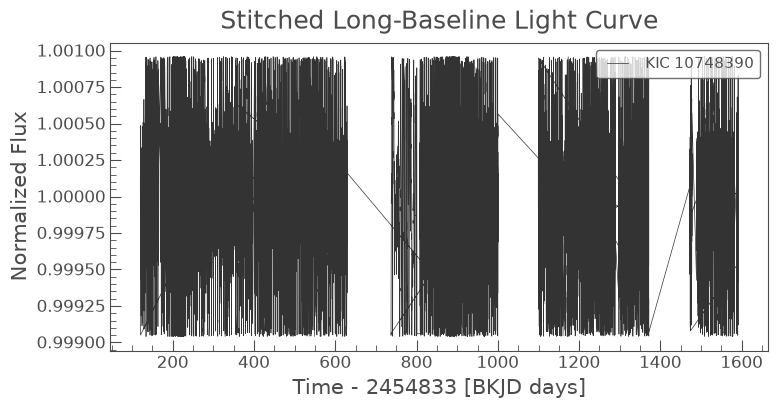

In [4]:
import lightkurve as lk
import matplotlib.pyplot as plt

target_name = 'HAT-P-11'

# 1. Search for all available Kepler quarters for the target
search_all = lk.search_lightcurve(target_name, author='Kepler')
print(f"Found {len(search_all)} quarters of data.")

# 2. Download all the light curve files into a LightCurveCollection
print("Downloading...")
lc_collection = search_all.download_all()

# 3. Stitch them together while automatically flattening and normalizing each quarter
# (The corrector_func handles scaling so quarters line up perfectly)
print("Stitching...")
stitched_lc = lc_collection.stitch(corrector_func=lambda x: x.flatten(window_length=401))

# 4. Remove bad data outliers and plot the long-baseline dataset
print("Plotting...")
stitched_lc = stitched_lc.remove_outliers()
stitched_lc.plot(title="Stitched Long-Baseline Light Curve");


In [ ]:
# Define your desired filename
fits_filename = "data/hatp11_stitched_lightcurve.fits"

# Export the stitched light curve to a FITS file
# overwrite=True prevents errors if you run the cell multiple times
stitched_lc.to_fits(fits_filename, overwrite=True)

print(f"Successfully saved light curve to {fits_filename}!")


Successfully saved light curve to hatp11_stitched_lightcurve.fits!
